# About this Notebook

- **Data**: https://www.kaggle.com/datasets/waddahali/order-delivery-dataset
  
  
- **EDA**: https://www.kaggle.com/code/rudraprasadbhuyan/business-questions-order-delivery-eda
- **Geo EDA**: https://www.kaggle.com/code/rudraprasadbhuyan/order-delivery-geo-eda


- **Project 1:**
  - Predict the Delivery Time (Regression)
  - https://www.kaggle.com/code/rudraprasadbhuyan/project-1-predict-delivery-time
- **PROJECT 2**
  - Predict Order Cancellation (Classification)
  - https://www.kaggle.com/code/rudraprasadbhuyan/project-2-predict-order-cancellation
- **PROJECT 3**
    - Delivery Delay Risk Model
    - https://www.kaggle.com/code/rudraprasadbhuyan/project-3-delivery-delay-risk-model
- **PROJECT 4**
  - Driver Ranking System
  - https://www.kaggle.com/code/rudraprasadbhuyan/project-4-driver-ranking-system/

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\Rudra\Desktop\kaggle\order-delivery\talabat_enhanced_orders.csv"

df = pd.read_csv(path)

# 1. Driver Stats

In [11]:
driver_stats =  df.groupby("Driver_ID").agg(
    avg_time = ("Delivery_Duration_Minutes", "mean"),
    avg_distance = ("Delivery_Distance_km", "mean"),
    total_orders = ("Order_ID", "count"),
    success_rate = ("Order_Status", lambda x: (x == "Delivered").mean())
)

driver_stats

,avg_time,avg_distance,total_orders,success_rate
Driver_ID,,,,
1,38.323944,2.145233,213,0.812207
2,37.706468,2.293293,201,0.845771
3,38.168367,2.207418,196,0.882653
4,37.521951,2.213860,205,0.814634
5,38.668246,2.150141,211,0.838863
...,...,...,...,...
496,36.131313,2.107907,198,0.848485
497,38.079602,2.313684,201,0.810945
498,37.892157,2.192323,204,0.872549


# 2. Efficiency Score

In [14]:
driver_stats["time_score"] = 1 / driver_stats["avg_time"]

driver_stats["final_score"] = (
    0.5 * driver_stats["time_score"] +
    0.3 * driver_stats["success_rate"] +
    0.2 * (driver_stats["total_orders"] / driver_stats["total_orders"].max())
)

driver_stats["final_score"]

Driver_ID
1      0.434951
2      0.435193
3      0.441913
4      0.429264
5      0.441158
         ...   
496    0.434074
497    0.424615
498    0.445671
499    0.421169
500    0.423296
Name: final_score, Length: 500, dtype: float64

# 3. Rank Drivers

In [17]:
driver_stats = driver_stats.sort_values("final_score", ascending=False)

print("Top 5 Drivers")
display(driver_stats.head())

print("Worst 5 Drivers")
display(driver_stats.tail())

Top 5 Drivers


,avg_time,avg_distance,total_orders,success_rate,time_score,final_score
Driver_ID,,,,,,
285,37.232759,2.223836,232,0.887931,0.026858,0.473951
42,37.813559,2.248347,236,0.877119,0.026446,0.473848
327,37.743590,2.216354,234,0.876068,0.026495,0.471884
52,36.810345,2.170840,232,0.870690,0.027166,0.468932
353,36.815315,2.275009,222,0.896396,0.027163,0.468274


Worst 5 Drivers


,avg_time,avg_distance,total_orders,success_rate,time_score,final_score
Driver_ID,,,,,,
244,38.485876,2.090882,177,0.813559,0.025984,0.405177
478,38.442529,2.147740,174,0.810345,0.026013,0.401717
273,36.870968,2.184701,155,0.845161,0.027122,0.396816
145,36.569697,2.184333,165,0.812121,0.027345,0.395384
103,37.017544,2.260357,171,0.795322,0.027014,0.395200


# Viz

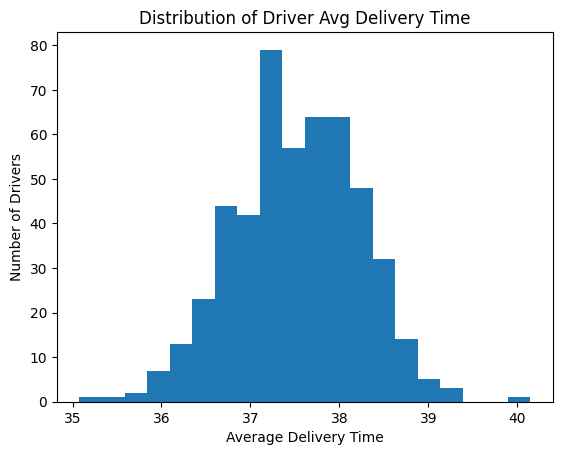

In [18]:
plt.figure()
plt.hist(driver_stats["avg_time"], bins=20)
plt.title("Distribution of Driver Avg Delivery Time")
plt.xlabel("Average Delivery Time")
plt.ylabel("Number of Drivers")
plt.show()

- The list is so on 
- So now done. 
- Meet you on next notebook series